## Loading experiment results

In Mozaik, experiment results are stored in a database called Data Store. In its current implementation, the DataStore is stored as a collection of .pickle files in the results directory of the simulation. It is stored in the following files:

- SegmentX.pickle - Used for storing neural recordings. For each stimulus and each sheet you record from, one Segment is created. So with 2 LGN sheets (ON & OFF cells), and 4 cortical sheets (excitatory and inhibitory cells of Layer 4 and Layer 2/3), 6 Segments are created for each stimulus, as we record some neural activity from all simulated sheets.
- datastore.recordings.pickle - Used for storing references and metadata for the segments. Indispensable for loading the datastore.
- datastore.analysis.pickle - Used for storing analysis results. 
- datastore.sensory.stimulus.pickle - Used for storing the visual stimuli used in experiments. Most of the time almost empty, as we don't store those by default.


Once a simulation has successfully run, you should see all datastore files and at least one Segment in the results directory. If they are not there (especially if you see Segments but no datastore files), the simulation most likely crashed for some reason and needs to be rerun.

In [11]:
import os

# Path to your local copy of the library
target_file = 'parameters/__init__.py'

if os.path.exists(target_file):
    print(f"Reparing {target_file}...")
    
    with open(target_file, 'r') as f:
        lines = f.readlines()

    # 1. Remove the incorrectly placed line (from the previous fix)
    clean_lines = [line for line in lines if "from urllib.request import HTTPHandler" not in line]

    # 2. Find the correct insertion point (after any __future__ imports)
    insert_index = 0
    for i, line in enumerate(clean_lines):
        if line.startswith("from __future__"):
            insert_index = i + 1
    
    # 3. Insert the fix at the safe position
    print(f"Inserting fix at line {insert_index}...")
    clean_lines.insert(insert_index, "from urllib.request import HTTPHandler, build_opener, install_opener, ProxyHandler\n")

    # 4. Save the file
    with open(target_file, 'w') as f:
        f.writelines(clean_lines)
        
    print("Success! File repaired.")
    print("PLEASE RESTART YOUR KERNEL AGAIN (Kernel -> Restart).")
else:
    print(f"Error: Could not find {target_file}. Make sure you are in the directory where you ran the previous setup script.")

Reparing parameters/__init__.py...
Inserting fix at line 51...
Success! File repaired.
PLEASE RESTART YOUR KERNEL AGAIN (Kernel -> Restart).


In [12]:
%matplotlib inline
from mozaik.storage.datastore import PickledDataStore
from parameters import ParameterSet
from mozaik.storage.queries import param_filter_query
from mozaik.tools.distribution_parametrization import load_parameters
import logging
import sys
from mozaik.storage.queries import *
from mozaik.analysis.analysis import *
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
from mozaik.storage.datastore import DataStoreView
import matplotlib.pyplot as plt
import numpy as np

# Path to the experiment DataStore
# Substitute this path with the path of your own simulation run!
# path = "SelfSustainedPushPull_test_____"
path = "SelfSustainedPushPull_trial1_chunk2_____"

data_store = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": path, "store_stimuli": False}),
    replace=False,
)

## Datastore contents - LSV1M

If you ran the experiments for the first version of our model (LSV1M), you should see all stimuli (InternalStimulus, FullfieldDriftingSinusoidalGrating, NaturalImageWithEyeMovement, EndOfSimulationBlank) below. Additionally, you can see the analysis results (Analysis Data Structures - ADS) saved into the data store.

In [13]:
data_store.print_content()

INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 10518
INFO:Mozaik:     InternalStimulus : 6984
INFO:Mozaik:     PixelMovieExperanto : 3534
INFO:Mozaik:   Number of ADS: 0


In [23]:
dsv = param_filter_query(
        data_store, st_name="PixelMovieExperanto", sheet_name="X_ON"
    )
dsv.print_content()

INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 589
INFO:Mozaik:     PixelMovieExperanto : 589
INFO:Mozaik:   Number of ADS: 0


In [24]:
segs, stims = dsv.get_segments(), dsv.get_stimuli()
len(segs[0].get_spiketrains())

7200

In [5]:
segs, stims = dsv.get_segments(), dsv.get_stimuli()
bin_size = 1 / 8 * 1000
duration = load_parameters(stims[0])["duration"]
num_trials = load_parameters(data_store.get_experiment_parametrization_list()[0][1])["num_trials"]

spikes_all_stimuli = np.zeros((num_trials, len(segs)//num_trials, len(segs[0].get_spiketrains()), int(np.ceil(duration/bin_size))))
for i in range(spikes_all_stimuli.shape[0]): # Number of trials 
    for j in range(spikes_all_stimuli.shape[1]): # Number of Stimuli
        for k in range(spikes_all_stimuli.shape[2]): # Number of neurons
            spike_times = np.array(segs[i*j].get_spiketrains()[k])
            valid_spikes = spike_times[spike_times < duration]
            spike_indices, counts = np.unique(valid_spikes // bin_size, return_counts=True)
            spikes_all_stimuli[i,j,k,spike_indices.astype(int)] += counts
print(spikes_all_stimuli.shape)

(10, 1, 2555, 4)


In [9]:
segs, stims = dsv.get_segments(), dsv.get_stimuli()
bin_size = 1 / 8 * 1000
duration = load_parameters(stims[0])["duration"]
# num_trials = load_parameters(data_store.get_experiment_parametrization_list()[0][1])["num_trials"]

spikes_all_stimuli = np.zeros((num_trials, len(segs)//num_trials, len(segs[0].get_spiketrains()), int(np.ceil(duration/bin_size))))

NameError: name 'num_trials' is not defined

In [7]:
i = 1
k = 5
segs, stims = dsv.get_segments(), dsv.get_stimuli()
print(segs[i].get_spiketrains()[k])
segs[i].get_spiketrains()[k]

[] ms


SpikeTrain containing 0 spikes; units ms; datatype float64 
annotations: {'source_population': 'V1_Exc_L2/3',
  'source_id': 61291,
  'source_index': 5,
  'channel_id': 61291}
time: 0.0 ms to 497.0 ms

37500

In [57]:
num_spikes = []
for neuron in range(len(segs[0].get_spiketrains())):
    # print(np.array(segs[i].get_spiketrains()[neuron]))
    a = len(segs[i].get_spiketrains()[neuron])
    num_spikes.append(a)

<BarContainer object of 13 artists>

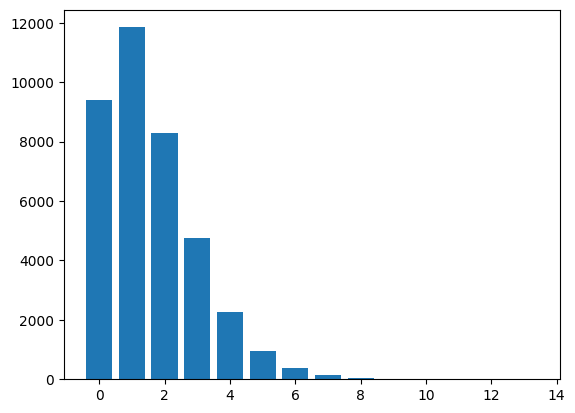

In [66]:
unique, counts = np.unique(num_spikes, return_counts=True)
plt.bar(unique, counts)

In [73]:
np.array(segs[i].get_spiketrains()[4323])

array([ 37. ,  40.7,  97. , 106.2, 109.3, 164.9, 238.5, 254.5, 310.3,
       328.6, 340. , 395.7, 460.8])

In [56]:
(spikes_all_stimuli[0][6] == spikes_all_stimuli[0][0]).all() # ALL the stimuli have the same pattern.

True

In [16]:
load_parameters(stims[0])

{'module_path': 'mozaik.stimuli.vision.topographica_based',
 'background_luminance': 50.0,
 'density': 13.090907186777137,
 'direct_stimulation_name': None,
 'direct_stimulation_parameters': None,
 'duration': 497.0,
 'frame_duration': 7.0,
 'frame_offset': 0,
 'location_x': 0.0,
 'location_y': 0.0,
 'movie_frame_duration': 497.0,
 'movie_name': '00005.npy',
 'movie_path': '/data/dynamic29513-my-test/screen/data',
 'name': 'PixelMovieExperanto',
 'size': 11,
 'size_x': 11.0,
 'size_y': 11.0,
 'trial': 1,
 'video_max_value': 255.0,
 'x_location': 0.0,
 'y_location': 0.0}

In [10]:
len(segs)//num_trials

7

In [17]:
stims[0]

'{"module_path" :"mozaik.stimuli.vision.topographica_based","background_luminance":50.0, "density":13.090907186777137, "direct_stimulation_name":None, "direct_stimulation_parameters":None, "duration":497.0, "frame_duration":7.0, "frame_offset":0, "location_x":0.0, "location_y":0.0, "movie_frame_duration":497.0, "movie_name":\'00011.npy\', "movie_path":\'/data/dynamic29513-my-test/screen/data\', "name":\'PixelMovieExperanto\', "size":11, "size_x":11.0, "size_y":11.0, "trial":0, "video_max_value":255.0, "x_location":0.0, "y_location":0.0}'

## Neuron positions for recorded spikes

Fist, let's visualize the positions of neurons from which we record spikes in excitatory layers 4 and 2/3. Mozaik allows the recording from  just a subset (or subsets) of the entire neural population. Here, we record using a dense grid in the middle of the cortex, and a sparser grid towards the periphery of the simulated regions. However, the density of the model is constant across space - we simulate the same number of neurons per area in the periphery as in the center, we just don't record from them to save disk space.



Layer: V1_Exc_L4

DataStoreView contents:
INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 0
INFO:Mozaik:   Number of ADS: 0


IndexError: list index out of range

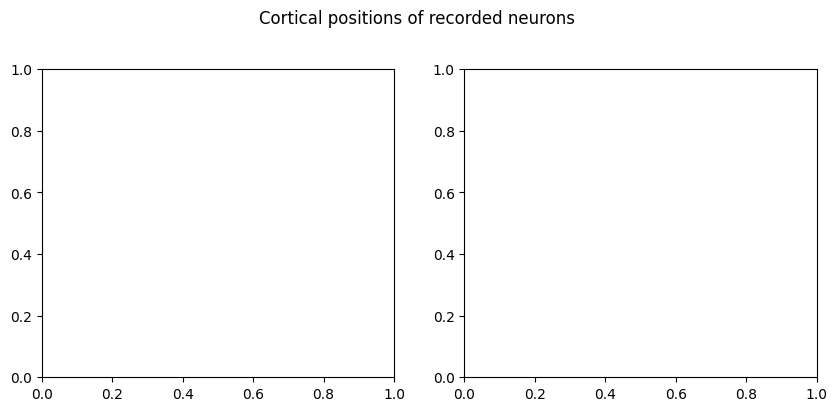

In [9]:
excitatory_cortical_layers = ["V1_Exc_L4", "V1_Exc_L2/3"]
fig, ax = plt.subplots(1,2,figsize=(10,4))

plt.suptitle("Cortical positions of recorded neurons",y=1.03)
for i, sheet in enumerate(excitatory_cortical_layers):
    # We can query the DataStore for the results we want
    # It returns a DataStoreView, a slice of the DataStore
    # Here we want the slice of the datastore that has recordings of
    # the natural image experiment, in the cortical layer we are looking at
    print("\n\nLayer: %s\n" % sheet)
    dsv = param_filter_query(
        data_store, st_name="FullfieldDriftingSinusoidalGrating", sheet_name=sheet
    )
    print("DataStoreView contents:")
    dsv.print_content()
    print("\nExample of a single stimulus:\n", dsv.get_stimuli()[0])

    # Get ids of neurons where spike trains were recorded in the sheet during this experiment
    st_ids = dsv.get_segments()[0].get_stored_spike_train_ids()

    # Retrieve and plot x,y positions of recorded neurons
    pos = dsv.get_neuron_positions()[sheet][:, dsv.get_sheet_indexes(sheet, st_ids)]
    ax[i].set_title(sheet)
    ax[i].plot(pos[0, :], pos[1, :], "ok")
    ax[i].set_xlabel("X (mm)")
    ax[i].set_ylabel("Y (mm)")
    ax[i].set_aspect('equal', adjustable='box')
plt.show()

## Plot spike times for neurons near the middle of the cortex

Next, let's select some stimuli using our DataStore filtering tool. As an example, we will filter out stimuli with the name `FullfieldDriftingSinusoidalGrating`, where the grating orientation is 0° and the grating contrast is 100%, for both excitatory layer 4 and 2/3.

Then, let's show the spiking activity for neurons located in the middle of the cortex - for this, we retrieve spatial positions, select the IDs of neurons which are in a radius of 100um in the middle of the cortex, and plot the spiketrains for only those neurons for two example trials. 

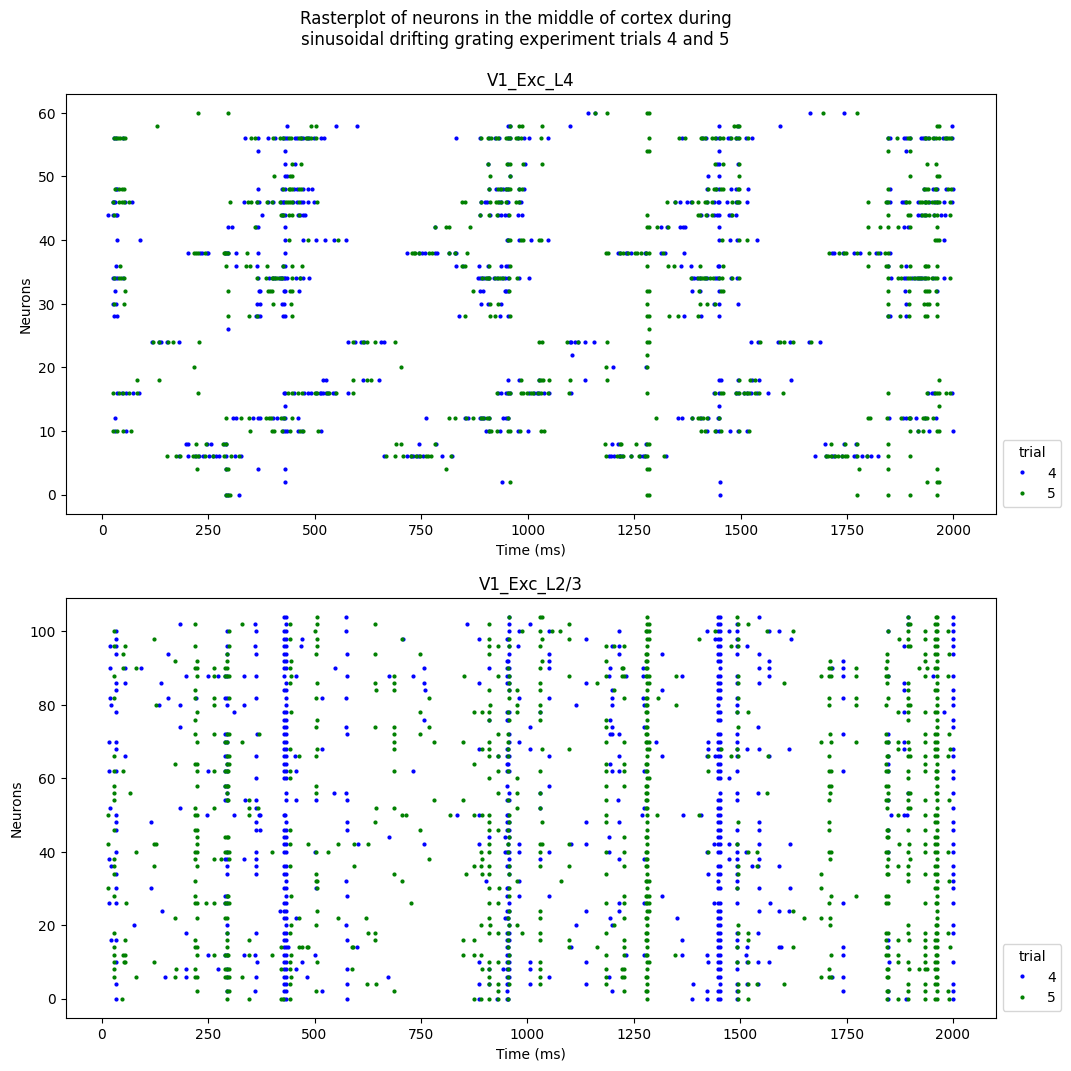

In [4]:
fig, ax = plt.subplots(2,1,figsize=(12,12))

plt.suptitle(
    "Rasterplot of neurons in the middle of cortex during\nsinusoidal drifting grating experiment trials 4 and 5",y=0.95
)
for i, sheet in enumerate(excitatory_cortical_layers):
    dsv = param_filter_query(
        data_store, st_name="FullfieldDriftingSinusoidalGrating", st_orientation=0, st_contrast=100, sheet_name=sheet
    )
    st_ids = dsv.get_segments()[0].get_stored_spike_train_ids()
    pos = dsv.get_neuron_positions()[sheet][:, dsv.get_sheet_indexes(sheet, st_ids)]
    # You can stack queries like so:
    for trial in [4,5]:
        dsv_trial = param_filter_query(dsv, st_trial=trial)
        # Retrieve spike times
        st = dsv_trial.get_segments()[0].get_spiketrains()
        # Get which ids are near the middle of the cortex
        dist = np.sqrt(pos[0, :] ** 2 + pos[1, :] ** 2)
        select_ids = np.where(dist < 0.1)[0]  # 0.1 mm radius
        # Get spiketimes for these ids
        filtered_spiketimes = [st[s_id] for s_id in select_ids]
        # Plot
        for k in range(len(filtered_spiketimes)):
            color = "b" if trial == 4 else "g"
            label = trial if k == 0 else "_nolabel_"
            ax[i].plot(
                filtered_spiketimes[k],
                np.ones(len(filtered_spiketimes[k])) * k * 2,
                "o",
                color=color,
                label=label,
                ms=2,
                alpha=1,
            )
    ax[i].set_title(sheet)
    ax[i].legend(title="trial", bbox_to_anchor=(1, 0), loc="lower left")
    ax[i].set_xlabel("Time (ms)")
    ax[i].set_ylabel("Neurons")
plt.show()

## Analysis

Previously, we showed how to visualize the raw data Mozaik records. However, Mozaik also provides a range of pre-prepared useful analyses that we use in our workflow. To show an example of a basic analysis you can do, and how to deal with the datastore, we are first going to drop all analysis results from the datastore:

In [5]:
data_store.full_datastore.remove_ads_from_datastore()

This is because the same analysis data structure cannot be saved in the same datastore twice, and the LSV1M workflow by default already ran some of the analyses we will be running now.

You can see the analysis results now removed from the datastore: 

In [6]:
data_store.print_content()

INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 3744
INFO:Mozaik:     InternalStimulus : 12
INFO:Mozaik:     FullfieldDriftingSinusoidalGrating : 3600
INFO:Mozaik:     NaturalImageWithEyeMovement : 120
INFO:Mozaik:     EndOfSimulationBlank : 12
INFO:Mozaik:   Number of ADS: 0


We will run two analyses: one calculates **PSTH (PeriStimulus Timing Histogram)**, which is a metric estimating the instantaneous firing rate of neurons for a given stimulus by summing up the number of spikes in a time bin, and then dividing this sum by that time bin.

Next, we will calculate the **mean across trials** of this PSTH.

In [7]:
psth_bin_ms = 50
PSTH(data_store,ParameterSet({'bin_length': psth_bin_ms})).analyse()

TrialMean(
    param_filter_query(data_store.full_datastore, analysis_algorithm="PSTH"),
    ParameterSet({"vm": False, "cond_inh": False, "cond_exc": False}),
).analyse()

INFO:Mozaik:Starting PSTH analysis
INFO:Mozaik:Starting TrialMean analysis


We will show both **individual trial PSTHs** and the **mean PSTH across trials**:

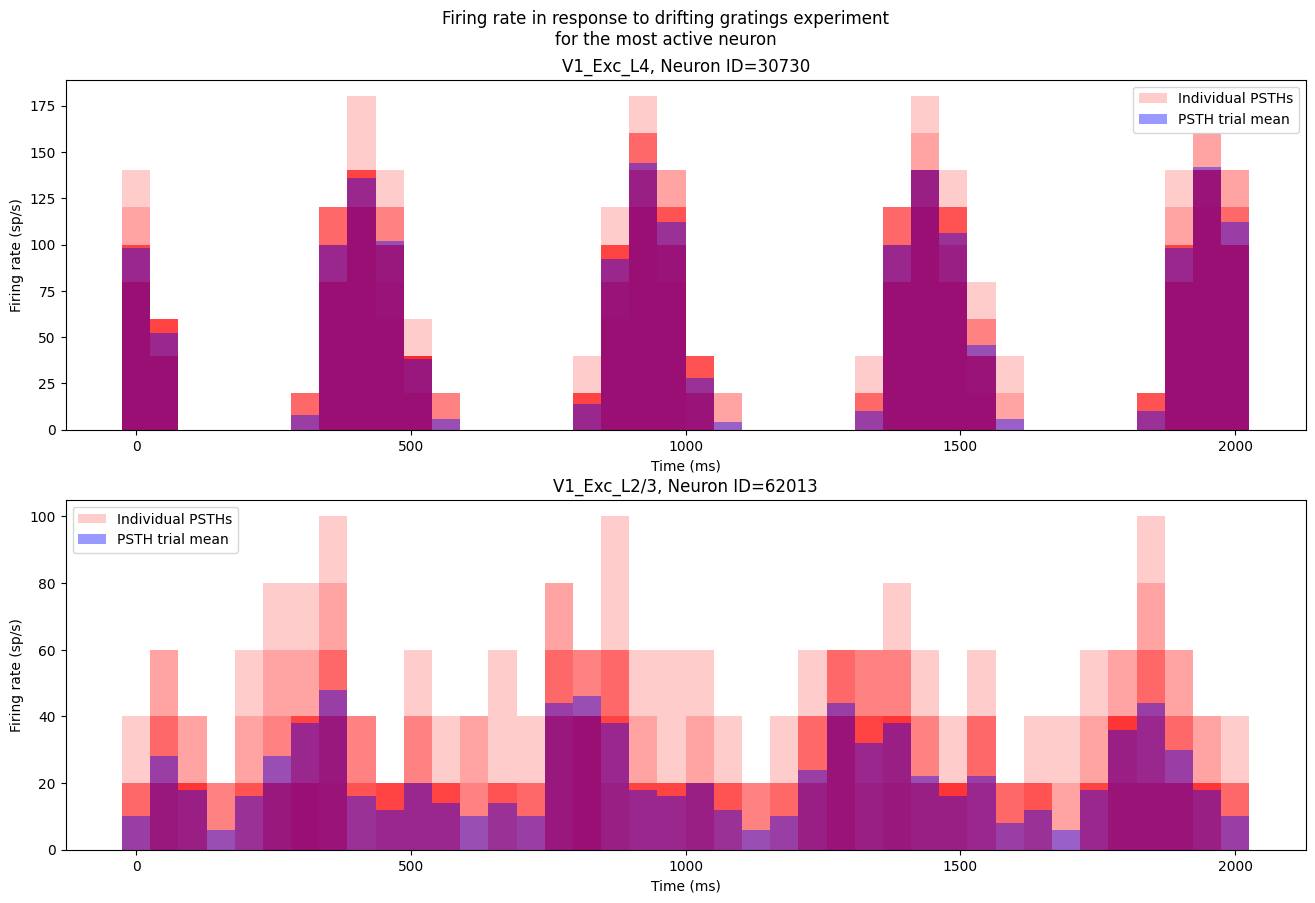

In [8]:
fig, ax = plt.subplots(2,1,figsize=(16,10))

plt.suptitle(
    "Firing rate in response to drifting gratings experiment\nfor the most active neuron",y=0.95
)
for i, sheet in enumerate(excitatory_cortical_layers):
    dsv = param_filter_query(
        data_store, st_name="FullfieldDriftingSinusoidalGrating", st_orientation=0, st_contrast=100, sheet_name=sheet
    )
    # Retrieve PSTH (Peristimulus Timing Histogram) analysis results
    psths_ar = dsv.get_analysis_result(
        analysis_algorithm="PSTH",
        sheet_name=sheet,
        y_axis_name="psth (bin=%d)" % psth_bin_ms,
    )
    mean_psth_ar = dsv.get_analysis_result(
        analysis_algorithm="TrialMean",
        sheet_name=sheet,
        y_axis_name="psth (bin=%d) trial-to-trial mean" % psth_bin_ms,
    )[0]
    
    # Plot the PSTHs, and mean PSTH of the neuron with the largest mean activity
    idx = np.argmax(np.sum(np.array(mean_psth_ar.asl).squeeze(), axis=1))
    n_id = mean_psth_ar.ids[idx]
    mean_psth = mean_psth_ar.asl[idx].squeeze()
    psths = [
        psth.asl[np.where(np.array(psths_ar[0].ids) == n_id)[0][0]].squeeze()
        for psth in psths_ar
    ]
    a = mean_psth
    t = np.linspace(0, psth_bin_ms * len(a), len(a), endpoint=True)
    first = True
    for aa in psths:
        label = None
        if first:
            label = "Individual PSTHs"
            first = False
        ax[i].bar(t, aa, width=(t[1] - t[0]), color="r", alpha=0.2, label=label)
    ax[i].bar(t, a, width=(t[1] - t[0]), color="b", label="PSTH trial mean", alpha=0.4)
    ax[i].set_title(f"{sheet}, Neuron ID={n_id}")
    ax[i].set_xlabel("Time (ms)")
    ax[i].set_ylabel("Firing rate (sp/s)")
    ax[i].legend()
plt.show()